# Task 1 — Diagnóstico, baselines e ARIMA/SARIMA

**Curso:** Séries Temporais · FGV EMAp · 2026/2

Três séries **diárias** da mesma loja Walmart (recorte M5 `CA_1`), já agregadas:

| Coluna | Série |
|---|---|
| `store_total` | total da loja |
| `FOODS` | categoria alimentos |
| `HOBBIES` | categoria hobbies |

O objetivo é prever os **28 dias** de 2016-03-28 a 2016-04-24 e comparar um
ARIMA/SARIMA contra quatro baselines simples.

## Roteiro

| Seção | Conteúdo |
|---|---|
| 0 | Setup — imports, constantes, configuração de gráficos |
| 1 | Os dados e o split temporal |
| 2 | Diagnóstico — série no tempo, outliers, sazonalidade, STL, estacionariedade, ACF/PACF |
| 3 | Os quatro baselines |
| 4 | Identificação da ordem — `D` pela força sazonal, `d` por KPSS iterativo, `p,q,P,Q` por grid de AICc |
| 5 | Previsão dos 28 dias |
| 6 | Métricas — MAE, RMSE e MASE na validação |
| 7 | Exportação de `previsoes_validacao.csv` e `metricas.csv` |
| 8 | Reprodução |

Rodar o notebook inteiro leva cerca de 6 minutos, quase todos no grid de AICc da
seção 4.

## 0. Setup

Imports, constantes do problema e configuração visual. Tudo que é fixo aparece
aqui uma única vez, para o resto do notebook não repetir número mágico.

Dois pontos sobre o ambiente:

- `torch` é instalado **fora** do `uv` (build ROCm para GPU AMD), então o import
  é protegido: o notebook roda inteiro sem ele. Veja o `README.md`.
- As figuras são salvas em `figuras/` além de aparecerem inline, para o
  diagnóstico ficar legível mesmo sem executar o notebook.

In [1]:
from __future__ import annotations

# --- BLAS em uma thread ----------------------------------------------------
# Duas camadas, porque uma só não cobre os dois modos de execução:
#
#   1. As variáveis de ambiente valem quando o processo é novo — `nbconvert`,
#      `python -m`, kernel recém-reiniciado. O OpenBLAS as lê ao carregar.
#   2. `threadpool_limits` age em tempo de execução, pela API da própria
#      biblioteca. É o que cobre o kernel quente do Jupyter ou do VS Code, em
#      que o numpy já foi importado e as variáveis chegam tarde demais.
#
# Importa para o resultado, não só para o tempo: com OpenBLAS multithread o
# L-BFGS percorre trajetórias diferentes entre execuções e o AICc deixa de ser
# reprodutível (medimos 18,1 e 27807,9 para o mesmo modelo). E sem a segunda
# camada, um "Run All" em kernel reaproveitado roda com 12 threads de BLAS por
# worker: ~84 threads disputando 12 núcleos, e o grid da seção 4 passa de
# 5 minutos para mais de 40.
import os

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import itertools
import multiprocessing as mp
import subprocess
import sys
import time
import warnings
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from threadpoolctl import threadpool_info, threadpool_limits
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning,
    EstimationWarning,
    InterpolationWarning,
)
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf

# torch vem de uma instalação ROCm separada; o notebook não depende dele.
try:
    import torch

    TORCH_OK = True
except ImportError:
    TORCH_OK = False

# Segunda camada. A referência é mantida porque o limite vale enquanto o
# objeto viver; os processos filhos herdam o limite pelo fork.
_BLAS = threadpool_limits(limits=1)

ROOT = Path.cwd()
DATA = ROOT / "dados"
FIGS = ROOT / "figuras"
FIGS.mkdir(exist_ok=True)

SERIES = ("store_total", "FOODS", "HOBBIES")
M = 7  # período sazonal: a semana
H = 28  # horizonte da Task 1
VAL_START = pd.Timestamp("2016-03-28")
VAL_END = pd.Timestamp("2016-04-24")
TREINO_FIM = pd.Timestamp("2016-03-27")

# --- busca de ordem --------------------------------------------------------
P_MAX = Q_MAX = 3  # p, q ∈ 0..3
PS_MAX = QS_MAX = 2  # P, Q ∈ 0..2
MAXITER = 200  # o default (50) não converge nas ordens maiores e enviesa o AICc
K_BT = 12  # origens do backtest que decide o D do HOBBIES
N_JOBS = min(6, os.cpu_count() or 1)

_threads_blas = {i["internal_api"]: i["num_threads"] for i in threadpool_info()}
assert all(n == 1 for n in _threads_blas.values()), (
    f"BLAS com mais de uma thread: {_threads_blas}. O grid da seção 4 levaria dezenas "
    "de minutos. Reinicie o kernel e rode de novo."
)

print(f"pandas {pd.__version__} | numpy {np.__version__} | torch disponível: {TORCH_OK}")
print(f"BLAS {_threads_blas} | pool de {N_JOBS} processos | {os.cpu_count()} CPUs")

pandas 3.0.6 | numpy 2.5.3 | torch disponível: False
BLAS {'openblas': 1} | pool de 6 processos | 16 CPUs


In [2]:
# --- paleta e estilo -------------------------------------------------------
# Cores categóricas validadas para daltonismo (ΔE CVD ≥ 9.2 entre todos os pares).
SURFACE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
LINHA = "#d8d7d2"
CORES = {"store_total": "#2a78d6", "FOODS": "#eb6834", "HOBBIES": "#1baf7a"}
DESTAQUE = "#e34948"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
    "figure.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": LINHA,
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "axes.titlelocation": "left",
    "axes.labelsize": 9,
    "axes.labelcolor": TINTA_2,
    "text.color": TINTA,
    "xtick.color": TINTA_2,
    "ytick.color": TINTA_2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})


def painel(n=3, altura=2.4, largura=11.0, ncols=1, sharex=True, sharey=False):
    """Uma figura com um painel por série (small multiples)."""
    fig, axes = plt.subplots(
        n, ncols, figsize=(largura, altura * n), sharex=sharex, sharey=sharey
    )
    return fig, np.atleast_1d(axes).ravel()


def salvar(fig, nome: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGS / nome)
    print(f"  → figuras/{nome}")


MESES_PT = ["jan", "fev", "mar", "abr", "mai", "jun",
            "jul", "ago", "set", "out", "nov", "dez"]


def eixo_mes(ax) -> None:
    """Rótulos de mês em português, para o gráfico não misturar idiomas."""
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _: f"{MESES_PT[mdates.num2date(x).month - 1]}/{mdates.num2date(x):%y}"
        )
    )

## 1. Os dados e o split temporal

Três arquivos em `data/`:

| Arquivo | Período | Tem `y`? |
|---|---|---|
| `treino.csv` | 2011-01-29 a 2016-03-27 | sim |
| `validacao.csv` | 2016-03-28 a 2016-04-24 | sim — **é o horizonte desta Task** |
| `holdout_datas.csv` | 2016-04-25 a 2016-05-22 | **não**, só as datas |

O `y` do holdout não faz parte desta entrega: ele é o score cego da A2. Por isso
ele aparece aqui só como lista de datas que **não podem** receber previsão.

In [3]:
train = pd.read_csv(DATA / "treino.csv", parse_dates=["date"]).sort_values("date")
val = pd.read_csv(DATA / "validacao.csv", parse_dates=["date"]).sort_values("date")
holdout = pd.read_csv(DATA / "holdout_datas.csv", parse_dates=["date"]).sort_values("date")

train = train.set_index("date").asfreq("D")
val = val.set_index("date").asfreq("D")

print(f"treino    {train.index.min().date()} → {train.index.max().date()}  ({len(train)} dias)")
print(f"validação {val.index.min().date()} → {val.index.max().date()}  ({len(val)} dias)")
print(f"holdout   {holdout['date'].min().date()} → {holdout['date'].max().date()}  ({len(holdout)} datas, sem y)")

treino    2011-01-29 → 2016-03-27  (1885 dias)
validação 2016-03-28 → 2016-04-24  (28 dias)
holdout   2016-04-25 → 2016-05-22  (28 datas, sem y)


### Integridade do split

Checagens que falham alto se algo estiver fora do lugar — é mais barato quebrar
aqui do que descobrir vazamento no fim.

In [4]:
assert train.index.max() == TREINO_FIM, "treino não termina em 2016-03-27"
assert val.index.min() == VAL_START and val.index.max() == VAL_END, "validação fora do horizonte"
assert len(val) == 28, "validação não tem 28 dias"
assert not train.index.has_duplicates and not val.index.has_duplicates
assert train.index.to_series().diff().dropna().eq(pd.Timedelta(days=1)).all(), "buraco de data no treino"
assert train.notna().all().all(), "NaN no treino"
assert train.index.max() < val.index.min() < pd.Timestamp(holdout["date"].min()), "ordem dos blocos errada"
assert set(SERIES) == set(train.columns) == set(val.columns)

print("split íntegro: treino < validação < holdout, sem buracos e sem NaN")

split íntegro: treino < validação < holdout, sem buracos e sem NaN


In [5]:
resumo = pd.DataFrame({
    "n": train.count(),
    "média": train.mean().round(1),
    "desvio": train.std().round(1),
    "mín": train.min(),
    "máx": train.max(),
    "mediana": train.median(),
}).loc[list(SERIES)]
resumo

,n,média,desvio,mín,máx,mediana
store_total,1885,4016.1,990.0,0,6948,3899.0
FOODS,1885,2809.6,701.2,0,5016,2710.0
HOBBIES,1885,457.1,123.6,0,953,458.0


### A regra anti-vazamento

> Se a informação não existiria em **2016-03-27**, ela não entra no treino.

Na prática, três consequências que valem **2,5 pontos** do critério de split:

1. Todo modelo é ajustado **só** com `treino.csv`. A validação nunca é usada no `fit`.
2. `previsoes_validacao.csv` só pode conter datas entre 2016-03-28 e 2016-04-24.
3. Nenhuma data do holdout aparece na entrega.

Como as séries são temporais, não existe embaralhar linhas: a ordem cronológica
é a informação.

## 2. Diagnóstico

Objetivo desta seção: entender **tendência**, **sazonalidade semanal** e
**outliers** antes de escolher qualquer modelo. É daqui que sai a ordem do
SARIMA.

### 2.1 A série no tempo

Primeiro a visão completa, 2011 a 2016. Um painel por série porque as escalas
são muito diferentes (`store_total` roda na casa dos milhares, `HOBBIES` nas
centenas) — sobrepor as três num eixo só esconderia a menor.

  → figuras/01_series_completas.png


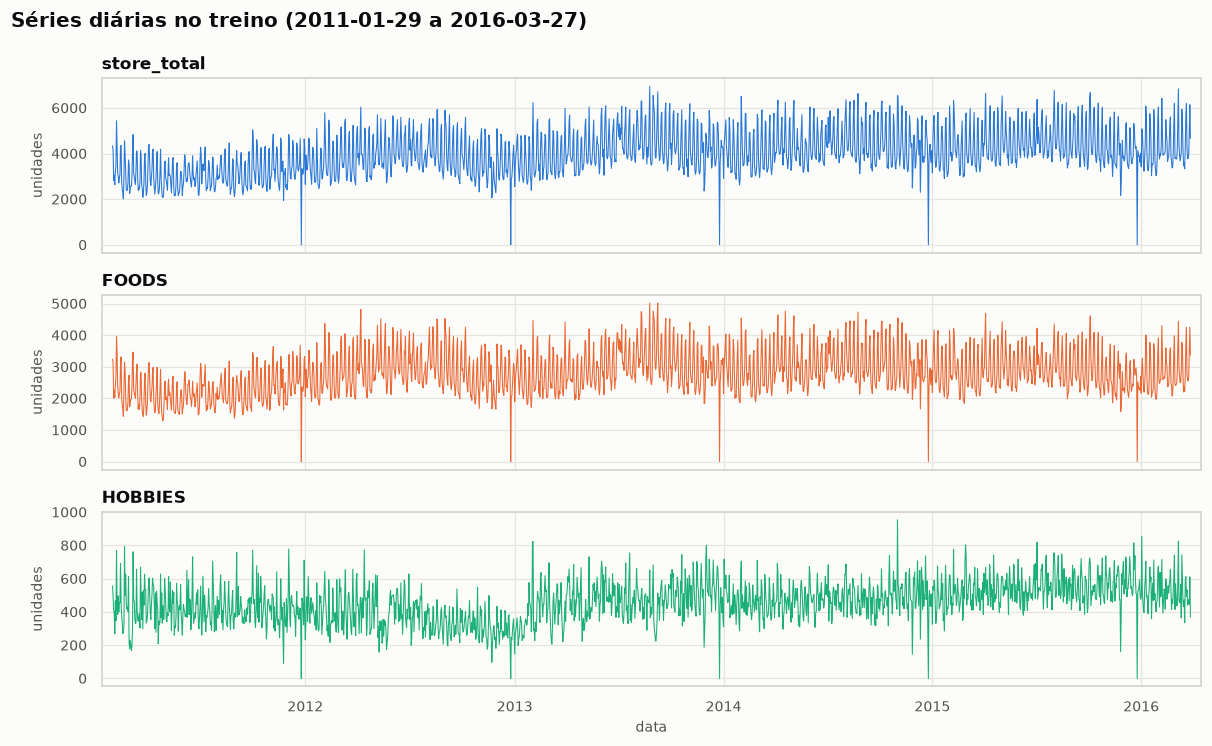

In [6]:
fig, axes = painel(3, altura=2.3)
for ax, s in zip(axes, SERIES):
    ax.plot(train.index, train[s], color=CORES[s], lw=0.7)
    ax.set_title(s)
    ax.set_ylabel("unidades")
    ax.margins(x=0.01)
axes[-1].set_xlabel("data")
fig.suptitle("Séries diárias no treino (2011-01-29 a 2016-03-27)", x=0.0, ha="left",
             fontsize=13, fontweight="bold")
salvar(fig, "01_series_completas.png")
plt.show()

Agora o zoom nos últimos 120 dias do treino, com o início da validação marcado.
É a janela que o modelo realmente "vê" ao prever, e onde a estrutura semanal
fica visível a olho nu.

  → figuras/02_series_zoom.png


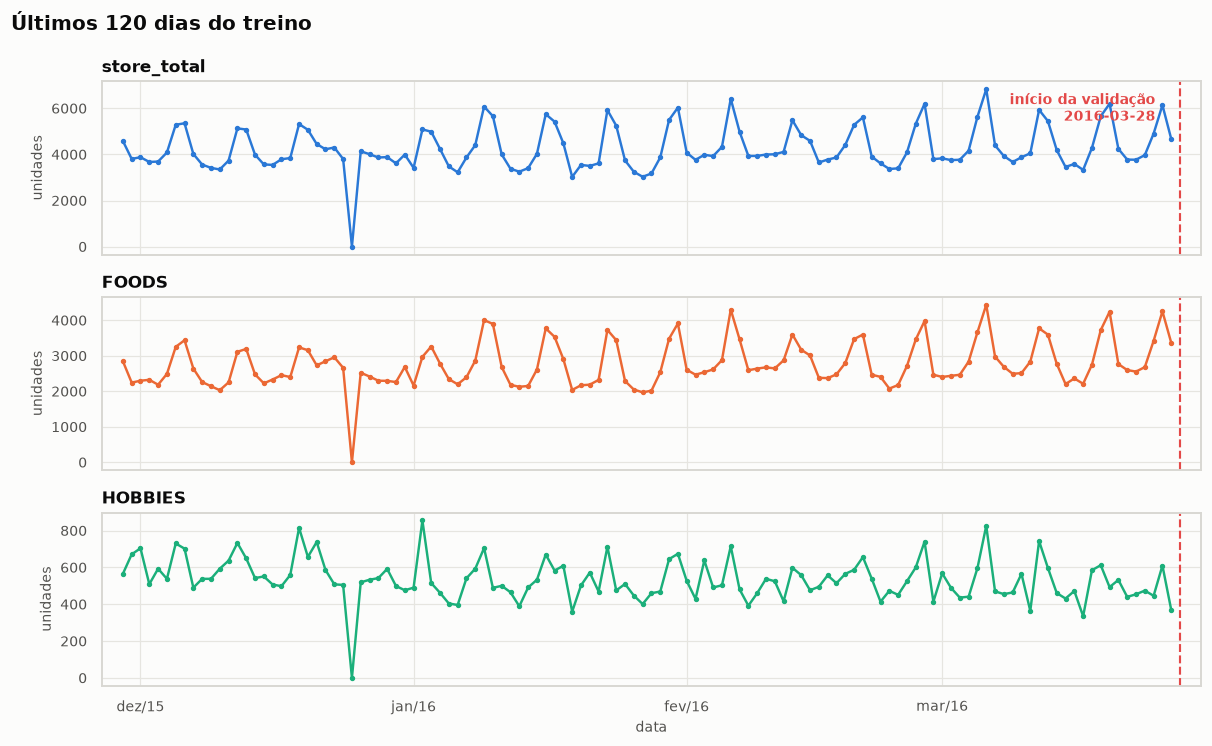

In [7]:
jan_ini = TREINO_FIM - pd.Timedelta(days=119)
fig, axes = painel(3, altura=2.3)
for ax, s in zip(axes, SERIES):
    janela = train.loc[jan_ini:, s]
    ax.plot(janela.index, janela, color=CORES[s], lw=1.6, marker="o", ms=2.5)
    ax.axvline(VAL_START, color=DESTAQUE, lw=1.4, ls="--")
    ax.set_title(s)
    ax.set_ylabel("unidades")
    ax.margins(x=0.02)
axes[0].annotate("início da validação\n2016-03-28", xy=(VAL_START, 0.94),
                 xycoords=("data", "axes fraction"), xytext=(-16, 0),
                 textcoords="offset points", ha="right", va="top",
                 fontsize=9, color=DESTAQUE, fontweight="bold")
eixo_mes(axes[-1])
axes[-1].set_xlabel("data")
fig.suptitle("Últimos 120 dias do treino", x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "02_series_zoom.png")
plt.show()

### 2.2 Outliers de calendário

O enunciado avisa que existem zeros de calendário. Vamos localizá-los.

In [8]:
zeros = train[(train[list(SERIES)] == 0).any(axis=1)]
print(f"{len(zeros)} dias com zero em alguma série:\n")
zeros.assign(dia=zeros.index.day_name())

5 dias com zero em alguma série:



,store_total,FOODS,HOBBIES,dia
date,,,,
2011-12-25,0,0,0,Sunday
2012-12-25,0,0,0,Tuesday
2013-12-25,0,0,0,Wednesday
2014-12-25,0,0,0,Thursday
2015-12-25,0,0,0,Friday


São exatamente **5 dias**, todos 25 de dezembro, e as três séries zeram juntas:
a loja fecha no Natal. Não é ruído de medição, é fechamento.

Mas o zero não está sozinho — a semana inteira de festas é um vale. Comparando
`store_total` (média geral ≈ 4027) nos dias ao redor:

In [9]:
anos = range(2011, 2016)
vizinhanca = pd.DataFrame(
    {
        rotulo: [train["store_total"].get(pd.Timestamp(f"{a + salto}-{mmdd}"), np.nan) for a in anos]
        for rotulo, mmdd, salto in [
            ("18/12", "12-18", 0), ("24/12", "12-24", 0), ("25/12", "12-25", 0),
            ("26/12", "12-26", 0), ("01/01", "01-01", 1),
        ]
    },
    index=[f"{a}" for a in anos],
).astype("Int64")
vizinhanca.index.name = "ano"
print(f"média geral de store_total (sem os zeros): {train['store_total'][train['store_total'] > 0].mean():.0f}\n")
vizinhanca

média geral de store_total (sem os zeros): 4027



,18/12,24/12,25/12,26/12,01/01
ano,,,,,
2011,4253,3454,0,3335,2648
2012,3277,3370,0,2862,2552
2013,3453,3458,0,3570,2913
2014,3836,3487,0,3593,3150
2015,3843,3803,0,4137,3418


  → figuras/03_zeros_natal.png


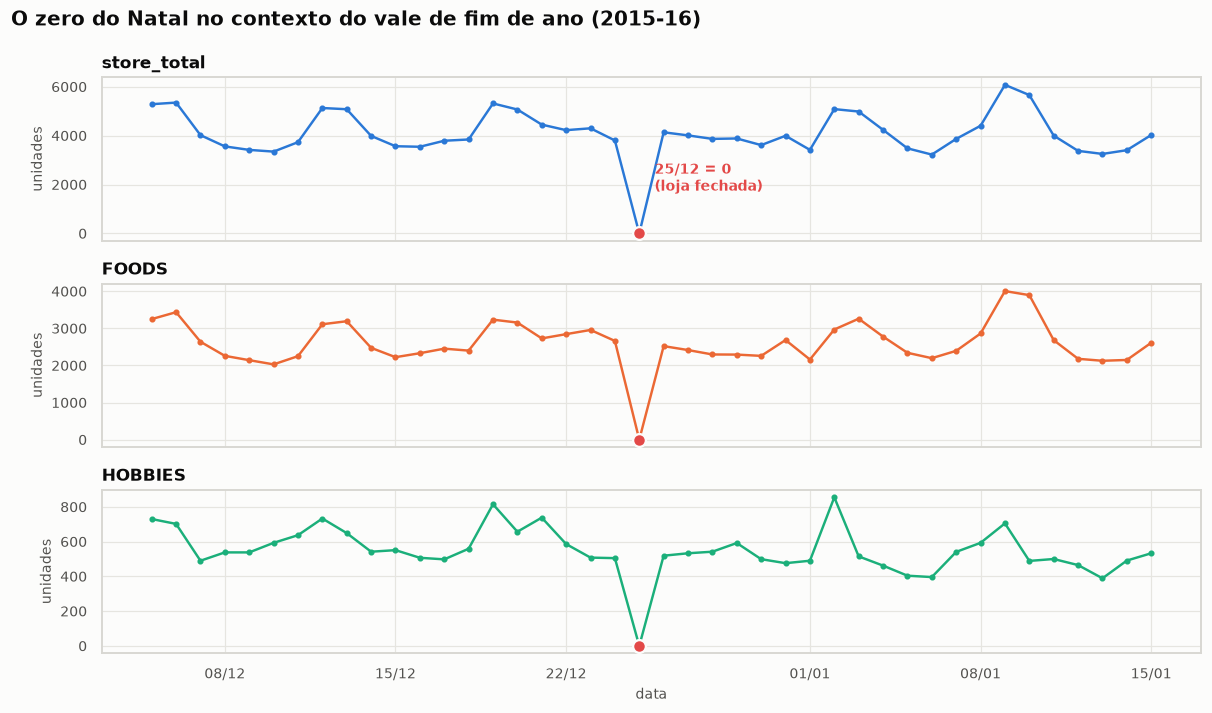

In [10]:
fig, axes = painel(3, altura=2.2)
ini, fim = pd.Timestamp("2015-12-05"), pd.Timestamp("2016-01-15")
for ax, s in zip(axes, SERIES):
    janela = train.loc[ini:fim, s]
    ax.plot(janela.index, janela, color=CORES[s], lw=1.6, marker="o", ms=3)
    natal = pd.Timestamp("2015-12-25")
    ax.scatter([natal], [train.loc[natal, s]], s=70, color=DESTAQUE, zorder=5,
               edgecolor=SURFACE, linewidth=1.5)
    ax.set_title(s)
    ax.set_ylabel("unidades")
axes[0].annotate("25/12 = 0\n(loja fechada)", xy=(pd.Timestamp("2015-12-25"), 0),
                 xytext=(10, 28), textcoords="offset points", fontsize=9,
                 color=DESTAQUE, fontweight="bold")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axes[-1].set_xlabel("data")
fig.suptitle("O zero do Natal no contexto do vale de fim de ano (2015-16)",
             x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "03_zeros_natal.png")
plt.show()

#### Decisão: interpolar os zeros, mas só para o SARIMA

O zero está a cerca de **4 desvios-padrão** abaixo da média. Na verossimilhança
gaussiana do SARIMA ele entra ao quadrado, então um único ponto desses pesa como
~17 pontos normais. Com diferenciação regular e sazonal, cada zero vira um par de
choques (queda + repique). Isso tem três efeitos ruins:

1. **Atenua o ACF/PACF** — o outlier infla a variância no denominador da
   autocorrelação, puxando todos os lags em direção a zero. São justamente esses
   gráficos que usamos para escolher a ordem.
2. **Infla a variância dos resíduos**, alargando os intervalos de previsão.
3. **Distorce o AIC**, que pode premiar a ordem que melhor absorve o Natal em vez
   da que melhor modela a semana.

Então criamos uma cópia interpolada para a identificação e o ajuste do SARIMA.
**Baselines e métricas continuam no dado cru** — a escala do MASE, em particular,
é obrigatoriamente calculada do CSV cru, para bater com a correção.

**Por que interpolação linear e não a média de ±7 dias?** Porque `25/12 + 7 = 01/01`,
que também é dia atípico (tabela acima: 2552 a 3418, contra média de 4027). A
interpolação linear usa 24/12 e 26/12, ambos dentro da mesma semana de festas —
vizinhança mais representativa. Repare na tabela abaixo que os valores
interpolados ficam na faixa dos 3100-3900, ou seja, **preservam o vale** de fim
de ano e removem só o zero artificial.

In [11]:
train_fit = train.copy()
train_fit[list(SERIES)] = train_fit[list(SERIES)].mask(train_fit[list(SERIES)] == 0).interpolate()

comparacao = pd.concat(
    [train.loc[zeros.index, list(SERIES)].add_suffix(" cru"),
     train_fit.loc[zeros.index, list(SERIES)].round(0).astype(int).add_suffix(" interp")],
    axis=1,
)[[f"{s} {k}" for s in SERIES for k in ("cru", "interp")]]
print("train      = dado cru      → baselines, métricas, escala do MASE")
print("train_fit  = interpolado   → ACF/PACF e ajuste do SARIMA\n")
comparacao

train      = dado cru      → baselines, métricas, escala do MASE
train_fit  = interpolado   → ACF/PACF e ajuste do SARIMA



,store_total cru,store_total interp,FOODS cru,FOODS interp,HOBBIES cru,HOBBIES interp
date,,,,,,
2011-12-25,0,3394,0,2559,0,408
2012-12-25,0,3116,0,2388,0,222
2013-12-25,0,3514,0,2552,0,409
2014-12-25,0,3540,0,2488,0,384
2015-12-25,0,3970,0,2592,0,512


In [12]:
# Efeito da interpolação na autocorrelação — é o que motiva a decisão.
efeito = pd.DataFrame(
    {
        s: {
            "ACF(1) cru": acf(train[s], nlags=1)[1],
            "ACF(1) interp": acf(train_fit[s], nlags=1)[1],
            "ACF(7) cru": acf(train[s], nlags=7)[7],
            "ACF(7) interp": acf(train_fit[s], nlags=7)[7],
        }
        for s in SERIES
    }
).round(4)
efeito

,store_total,FOODS,HOBBIES
ACF(1) cru,0.6172,0.6102,0.4845
ACF(1) interp,0.6350,0.6288,0.4949
ACF(7) cru,0.8124,0.7790,0.5247
ACF(7) interp,0.8355,0.8007,0.5336


### 2.3 Sazonalidade semanal

O enunciado já aponta `m = 7`. Vamos confirmar e medir o tamanho do efeito.

  → figuras/04_sazonalidade_semanal.png


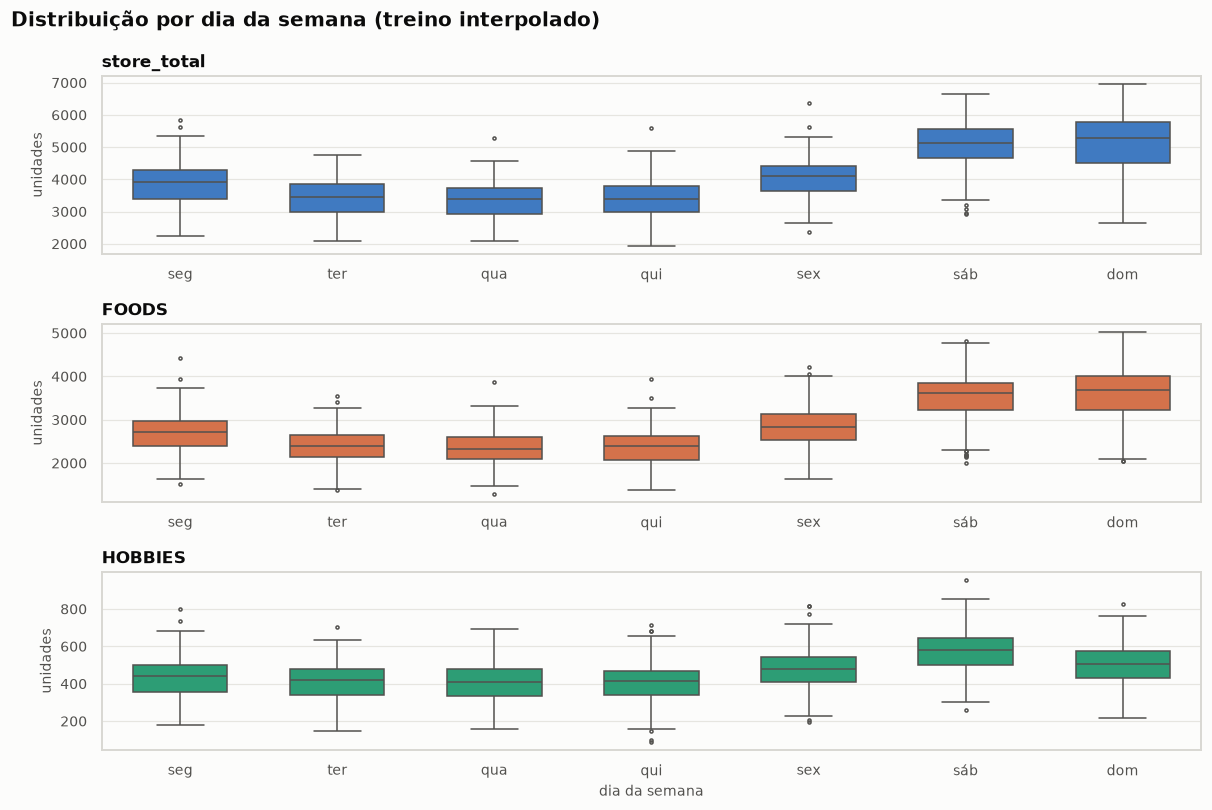

In [13]:
DIAS = ["seg", "ter", "qua", "qui", "sex", "sáb", "dom"]
longo = train_fit.copy()
longo["dia"] = pd.Categorical(
    [DIAS[d] for d in longo.index.dayofweek], categories=DIAS, ordered=True
)

fig, axes = painel(3, altura=2.5, sharex=False)
for ax, s in zip(axes, SERIES):
    sns.boxplot(data=longo, x="dia", y=s, ax=ax, color=CORES[s], width=0.6,
                linewidth=1.0, fliersize=2, linecolor=TINTA_2)
    ax.set_title(s)
    ax.set_xlabel("")
    ax.set_ylabel("unidades")
axes[-1].set_xlabel("dia da semana")
fig.suptitle("Distribuição por dia da semana (treino interpolado)", x=0.0, ha="left",
             fontsize=13, fontweight="bold")
salvar(fig, "04_sazonalidade_semanal.png")
plt.show()

In [14]:
perfil = longo.groupby("dia", observed=True)[list(SERIES)].mean()
indice = (perfil / perfil.mean() * 100).round(1)
indice.columns = [f"{c} (índice)" for c in indice.columns]
pd.concat([perfil.round(0).astype(int), indice], axis=1)

,store_total,FOODS,HOBBIES,store_total (índice),FOODS (índice),HOBBIES (índice)
dia,,,,,,
seg,3846,2690,431,95.6,95.5,94.2
ter,3417,2380,410,84.9,84.5,89.5
qua,3329,2322,406,82.7,82.5,88.7
qui,3367,2351,407,83.7,83.5,88.9
sex,4030,2826,474,100.1,100.4,103.4
sáb,5055,3522,571,125.6,125.1,124.8
dom,5127,3617,506,127.4,128.5,110.5


O índice é a média do dia dividida pela média geral, em base 100. Quanto mais
longe de 100, mais forte a sazonalidade semanal.

### 2.4 Decomposição STL

A STL separa a série em tendência + componente sazonal + resto. Serve para dois
fins aqui: visualizar os três ingredientes separados, e calcular a **força
sazonal**

$$F_s = \max\left(0,\; 1 - \frac{\operatorname{Var}(\text{resto})}{\operatorname{Var}(\text{resto} + \text{sazonal})}\right)$$

que é o critério de Wang-Smyth-Hyndman: $F_s > 0{,}64$ indica sazonalidade forte
o bastante para justificar **uma** diferenciação sazonal, ou seja $D = 1$.
A força de tendência $F_t$ é análoga, trocando sazonal por tendência.

  → figuras/05_stl.png


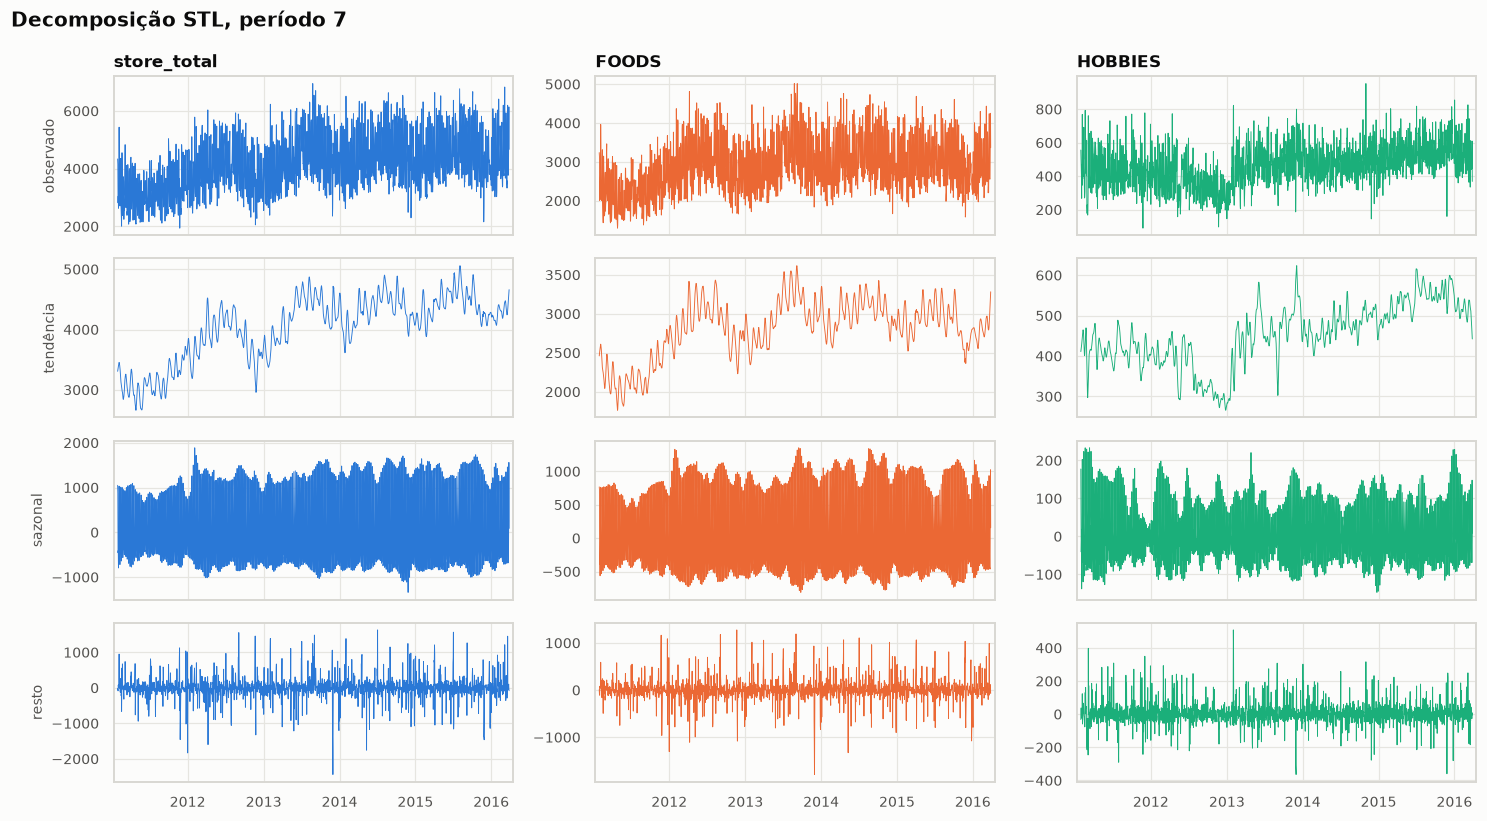

In [15]:
stl = {s: STL(train_fit[s], period=M, robust=True).fit() for s in SERIES}

fig, axes = painel(4, altura=1.9, ncols=3, largura=13.5, sharex=True)
axes = axes.reshape(4, 3)
componentes = ["observado", "tendência", "sazonal", "resto"]
for j, s in enumerate(SERIES):
    r = stl[s]
    for i, (nome, serie) in enumerate(
        zip(componentes, [train_fit[s], r.trend, r.seasonal, r.resid])
    ):
        ax = axes[i, j]
        ax.plot(serie.index, serie, color=CORES[s], lw=0.6)
        ax.margins(x=0.01)
        if i == 0:
            ax.set_title(s)
        if j == 0:
            ax.set_ylabel(nome)
fig.suptitle("Decomposição STL, período 7", x=0.0, ha="left", fontsize=13, fontweight="bold")
salvar(fig, "05_stl.png")
plt.show()

In [16]:
def forcas(res) -> dict[str, float]:
    resto, saz, tend = res.resid, res.seasonal, res.trend
    return {
        "F_sazonal": max(0.0, 1 - resto.var() / (resto + saz).var()),
        "F_tendência": max(0.0, 1 - resto.var() / (resto + tend).var()),
    }


tabela_forcas = pd.DataFrame({s: forcas(stl[s]) for s in SERIES}).T.round(3)
tabela_forcas["sugere D"] = (tabela_forcas["F_sazonal"] > 0.64).map({True: "1", False: "0"})
tabela_forcas

,F_sazonal,F_tendência,sugere D
store_total,0.837,0.734,1
FOODS,0.825,0.706,1
HOBBIES,0.465,0.526,0


### 2.5 Estacionariedade

Dois testes com hipóteses nulas **opostas**, por isso vale rodar os dois:

| Teste | H₀ | Rejeitar (p baixo) significa |
|---|---|---|
| **KPSS** | a série é estacionária | **não** é estacionária → diferenciar |
| **ADF** | a série tem raiz unitária | **é** estacionária → não diferenciar |

Rodamos em três versões de cada série: em nível, após diferenciação sazonal
$(1-B^7)$, e após sazonal + regular $(1-B)(1-B^7)$.

In [17]:
def kpss_teste(x) -> tuple[float, float, int]:
    """KPSS em nível. `result_object=True` evita o FutureWarning do statsmodels 0.15."""
    with warnings.catch_warnings():
        # o p-valor satura em 0,01 e 0,10, limites da tabela do teste
        warnings.simplefilter("ignore", InterpolationWarning)
        r = kpss(np.asarray(x, dtype=float), regression="c", nlags="auto", result_object=True)
    return float(r.statistic), float(r.pvalue), int(r.lags)


def adf_teste(x) -> tuple[float, float]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        r = adfuller(np.asarray(x, dtype=float), autolag="AIC", result_object=True)
    return float(r.statistic), float(r.pvalue)


def testes(x: pd.Series) -> dict[str, float]:
    x = x.dropna()
    kp_stat, kp_p, _ = kpss_teste(x)
    ad_stat, ad_p = adf_teste(x)
    return {"KPSS stat": kp_stat, "KPSS p": kp_p, "ADF stat": ad_stat, "ADF p": ad_p}


versoes = {
    "nível": lambda x: x,
    "diff sazonal (1-B⁷)": lambda x: x.diff(M),
    "sazonal + regular": lambda x: x.diff(M).diff(1),
}

estac = pd.DataFrame(
    {(s, nome): testes(f(train_fit[s])) for s in SERIES for nome, f in versoes.items()}
).T.round(4)
estac.index.names = ["série", "versão"]
estac["KPSS rejeita H₀"] = np.where(estac["KPSS p"] < 0.05, "sim → diferenciar", "não")
estac["ADF rejeita H₀"] = np.where(estac["ADF p"] < 0.05, "sim → estacionária", "não")
estac

KPSS stat  KPSS p  ADF stat   ADF p  \
série       versão                                                     
store_total nível                  11.8135    0.01   -2.0835  0.2512   
            diff sazonal (1-B⁷)     0.0093    0.10  -17.7269  0.0000   
            sazonal + regular       0.0264    0.10  -19.0924  0.0000   
FOODS       nível                   8.5439    0.01   -2.3898  0.1446   
            diff sazonal (1-B⁷)     0.0103    0.10  -15.1066  0.0000   
            sazonal + regular       0.0224    0.10  -20.0422  0.0000   
HOBBIES     nível                   5.0515    0.01   -2.9794  0.0369   
            diff sazonal (1-B⁷)     0.0075    0.10  -14.5118  0.0000   
            sazonal + regular       0.0202    0.10  -16.8198  0.0000   

                                   KPSS rejeita H₀      ADF rejeita H₀  
série       versão                                                      
store_total nível                sim → diferenciar                 não  
            diff sazonal (1-B⁷)                não  sim → estacionária  
            sazonal + regular                  não  sim → estacionária  
FOODS       nível                sim → diferenciar                 não  
            diff sazonal (1-B⁷)                não  sim → estacionária  
            sazonal + regular                  não  sim → estacionária  
HOBBIES     nível                sim → diferenciar  sim → estacionária  
            diff sazonal (1-B⁷)                não  sim → estacionária  
            sazonal + regular                  não  sim → estacionária

**Como ler**: o `d` sai de um KPSS iterativo — testa, se rejeitar diferencia e
testa de novo, até não rejeitar (máximo 2). O `D` **não** sai do KPSS: ele testa
estacionariedade em nível, e sazonalidade determinística forte faz o teste
rejeitar mesmo sem raiz unitária sazonal. Por isso o `D` vem da força sazonal da
seção 2.4, confirmada pelos correlogramas abaixo.

Nota sobre o `p` do KPSS: a tabela do teste vai de 0,01 a 0,10, então valores nos
extremos aparecem truncados (`0.01` significa "≤ 0,01").

### 2.6 ACF e PACF

Os correlogramas são a ferramenta de identificação da ordem. As linhas verticais
cinzas marcam os múltiplos de 7, e a faixa sombreada é a banda de confiança de
95% ($\pm 1{,}96/\sqrt{n}$): barras dentro da faixa são indistinguíveis de ruído.
Com $n \approx 1878$ a banda é estreita, $\pm 0{,}045$.

O **lag 0 é omitido** — ele vale 1 por definição e só comprimiria a escala dos
lags que interessam.

In [18]:
def correlogramas(dados: pd.DataFrame, transform, titulo: str, nome_arquivo: str, lags: int = 42):
    fig, axes = painel(3, altura=2.1, ncols=2, largura=13.0, sharex=True)
    axes = axes.reshape(3, 2)
    for i, s in enumerate(SERIES):
        x = transform(dados[s]).dropna()
        conf = 1.96 / np.sqrt(len(x))
        for j, (func, rotulo) in enumerate([(acf, "ACF"), (pacf, "PACF")]):
            vals = func(x, nlags=lags) if rotulo == "ACF" else func(x, nlags=lags, method="ywm")
            vals = vals[1:]  # lag 0 é sempre 1; omitido para não achatar a escala
            k = np.arange(1, len(vals) + 1)
            ax = axes[i, j]
            for L in range(M, lags + 1, M):
                ax.axvline(L, color=LINHA, lw=0.9, zorder=0)
            ax.axhspan(-conf, conf, color=TINTA_2, alpha=0.18, lw=0, zorder=1)
            ax.vlines(k, 0, vals, color=CORES[s], lw=1.8, zorder=3)
            ax.axhline(0, color=TINTA_2, lw=0.9, zorder=2)
            ax.set_title(f"{s} — {rotulo}")
            limite = max(0.25, np.abs(vals).max() * 1.15)
            ax.set_ylim(-limite, limite)
            ax.set_xlim(0.2, lags + 0.8)
            ax.set_xticks(range(0, lags + 1, M))
            if i == 2:
                ax.set_xlabel("lag (dias)")
    fig.suptitle(titulo, x=0.0, ha="left", fontsize=13, fontweight="bold")
    salvar(fig, nome_arquivo)
    plt.show()

  → figuras/06_acf_pacf_nivel.png


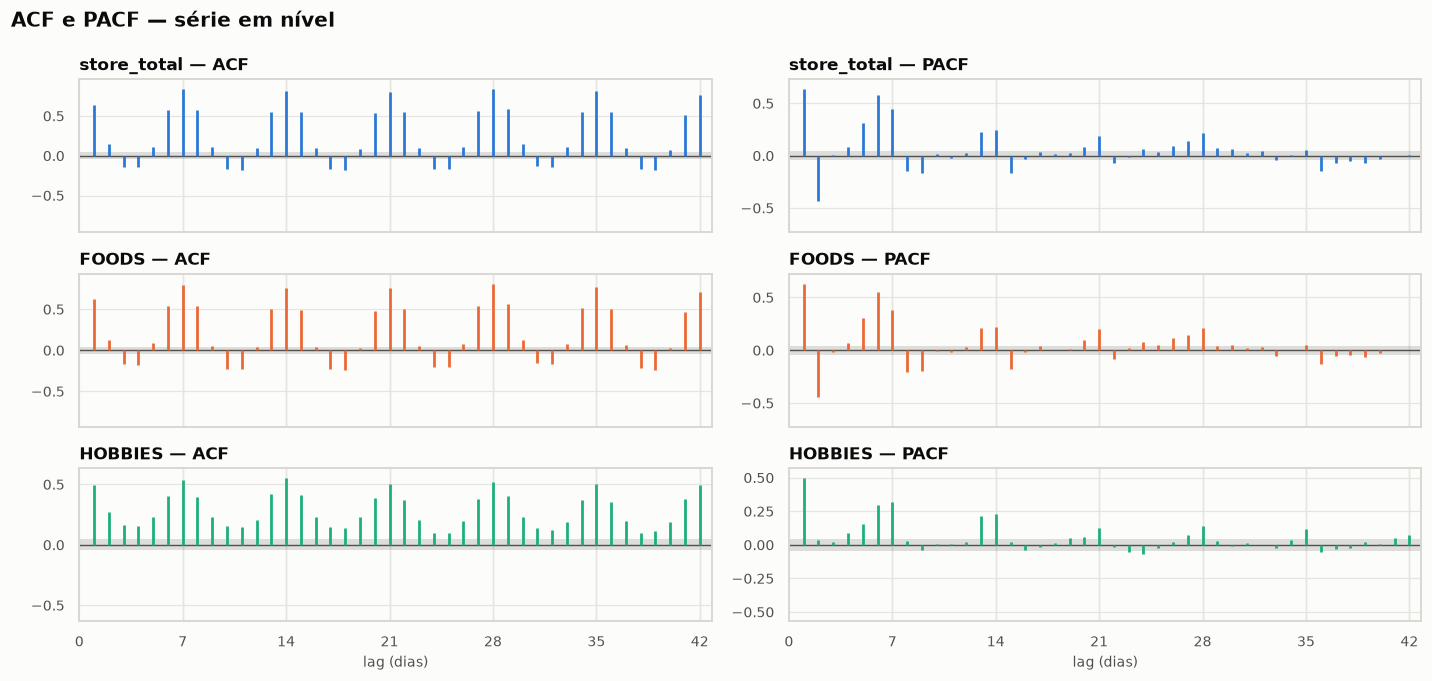

In [19]:
correlogramas(train_fit, lambda x: x,
              "ACF e PACF — série em nível", "06_acf_pacf_nivel.png")

#### O mesmo correlograma no treino cru

Os correlogramas desta seção usam `train_fit`, a cópia com os zeros de 25/12
interpolados, porque é ela que alimenta a identificação da ordem (seção 2.2). O
enunciado pede ACF e PACF **no treino**, então aqui está o mesmo gráfico sobre a
série crua, sem nenhum tratamento.

Os dois são visualmente indistinguíveis. A interpolação move a ACF do lag 7 de
**0,812 para 0,836** em `store_total` e de **0,525 para 0,534** em `HOBBIES` (tabela
da seção 2.2): efeito real, suficiente para justificar o tratamento no ajuste do
SARIMA, pequeno demais para mudar a leitura da ordem.

  → figuras/06b_acf_pacf_nivel_cru.png


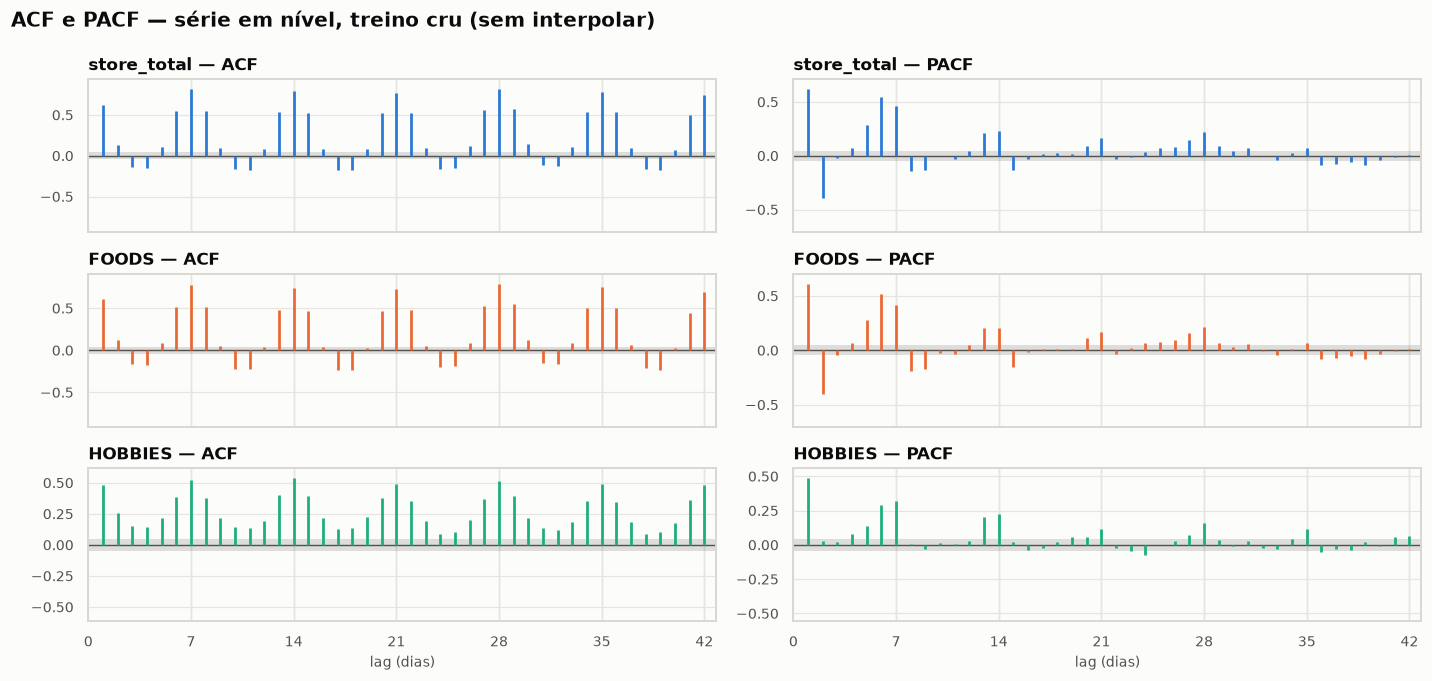

In [20]:
correlogramas(train, lambda x: x,
              "ACF e PACF — série em nível, treino cru (sem interpolar)",
              "06b_acf_pacf_nivel_cru.png")

  → figuras/07_acf_pacf_d7.png


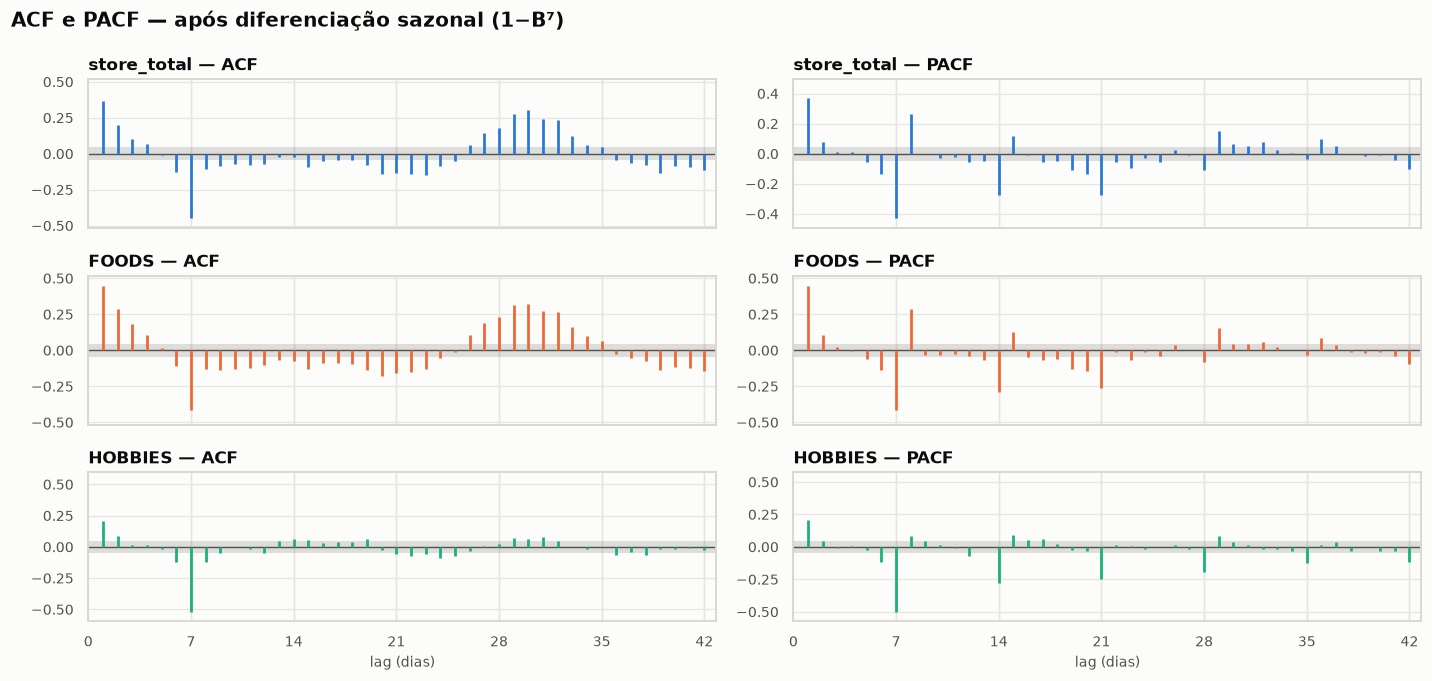

In [21]:
correlogramas(train_fit, lambda x: x.diff(M),
              "ACF e PACF — após diferenciação sazonal (1−B⁷)", "07_acf_pacf_d7.png")

  → figuras/08_acf_pacf_d7_d1.png


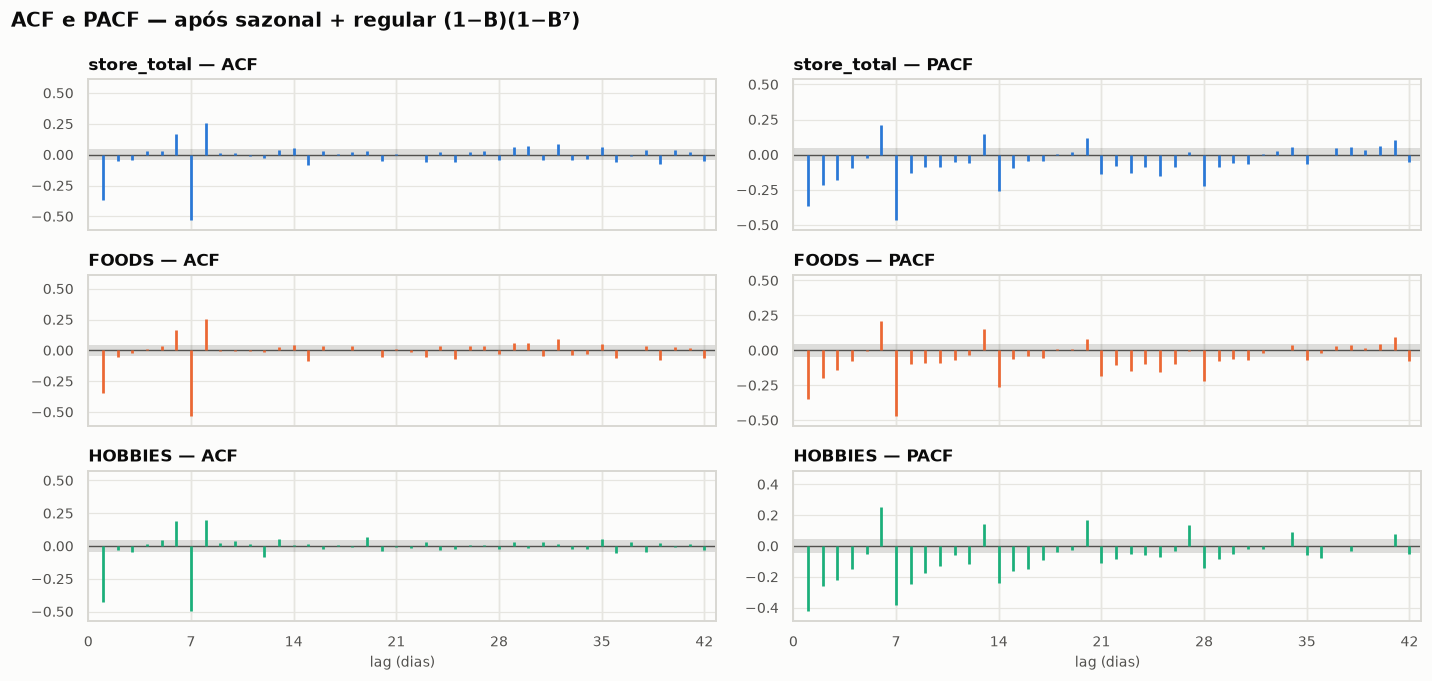

In [22]:
correlogramas(train_fit, lambda x: x.diff(M).diff(1),
              "ACF e PACF — após sazonal + regular (1−B)(1−B⁷)", "08_acf_pacf_d7_d1.png")

#### Os mesmos correlogramas em números

Ler barra por barra no gráfico é impreciso. A tabela abaixo traz os lags que
decidem a ordem. Valores com módulo abaixo de **0,045** estão dentro da banda de
confiança e devem ser lidos como zero.

In [23]:
LAGS_CHAVE = [1, 2, 3, 7, 14, 21, 28]

linhas = {}
for nome, f in versoes.items():
    for s in SERIES:
        x = f(train_fit[s]).dropna()
        a = acf(x, nlags=max(LAGS_CHAVE))
        p = pacf(x, nlags=max(LAGS_CHAVE), method="ywm")
        linhas[(nome, s, "ACF")] = {f"lag {k}": a[k] for k in LAGS_CHAVE}
        linhas[(nome, s, "PACF")] = {f"lag {k}": p[k] for k in LAGS_CHAVE}

correl = pd.DataFrame(linhas).T.round(3)
correl.index.names = ["versão", "série", "função"]
correl.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-0.6, vmax=0.6)

#### Guia de leitura

Para um $SARIMA(p,d,q)(P,D,Q)_7$:

| Onde olhar | O que decide | Regra |
|---|---|---|
| Lags 1, 2, 3 do **PACF** | `p` | corte abrupto após o lag $k$ → $p = k$ |
| Lags 1, 2, 3 do **ACF** | `q` | corte abrupto após o lag $k$ → $q = k$ |
| Lags 7, 14, 21 do **PACF** | `P` | mesma lógica, contando em múltiplos de 7 |
| Lags 7, 14, 21 do **ACF** | `Q` | mesma lógica |
| Decaimento lento no ACF | `d`, `D` | falta diferenciar |

Dois sinais clássicos:

- ACF decaindo devagar e PACF cortando no lag 1 → componente **AR**.
- ACF cortando no lag 1 e PACF decaindo → componente **MA**.
- Sobre-diferenciação aparece como um ACF fortemente negativo no lag 1
  (abaixo de −0,5), e é motivo para reduzir `d` ou `D`.

`d` e `D` ficam **fora** do grid de AIC que vem na próxima fase: o AIC não é
comparável entre modelos com diferenciação diferente, porque diferenciar muda a
própria série e o número de observações efetivas. Testes decidem `d` e `D`;
o AIC decide `p, q, P, Q`.

### 2.7 Resumo do diagnóstico

**Tendência.** `store_total` e `FOODS` sobem de ≈3000 em 2011 para ≈4500-5000 a
partir de 2013, com platô depois de 2014 (força de tendência 0,73 e 0,71).
`HOBBIES` tem tendência mais fraca e irregular (0,53), com um degrau claro no
começo de 2013: a tendência cai para ≈290 no fim de 2012 e sobe para ≈500 em
seguida.

**Sazonalidade semanal (m = 7).** Confirmada nas três séries. Em `store_total` o
índice por dia da semana vai de **82,7** (quarta) a **127,4** (domingo), uma
amplitude de 45 pontos. Sábado e domingo concentram o movimento; terça a quinta
são o vale. `HOBBIES` repete o padrão com amplitude menor (88,7 a 124,8). Mais
importante: em nível, a ACF nos lags 7, 14, 21 e 28 fica entre **0,80 e 0,84**
(`store_total`) **sem decair** — isso é não-estacionariedade sazonal, não apenas
sazonalidade.

**Outliers.** Cinco zeros, todos em 25/12, as três séries juntas: a loja fecha no
Natal. Tratados por interpolação linear apenas no pipeline do SARIMA (seção 2.2).
Não há outros faltantes nem buracos de data.

**Um terceiro ciclo, mensal.** Depois de $(1-B^7)$ a ACF volta a subir nos lags 28
a 32 (+0,18 a +0,30 em `store_total` e `FOODS`; ausente em `HOBBIES`). É
consistente com o ciclo mensal de pagamentos e do benefício SNAP, que afeta
alimentos. Um SARIMA com $m = 7$ não captura isso — fica registrado como
limitação conhecida do modelo, não como erro de ajuste.

#### O que os testes dizem sobre a diferenciação

| Evidência | Leitura |
|---|---|
| Em nível, KPSS rejeita nas três séries (p ≤ 0,01) e a ACF sazonal não decai | diferenciar |
| Após $(1-B^7)$: KPSS não rejeita (p = 0,10) e ADF rejeita raiz unitária (p < 0,001) | pelo KPSS iterativo, **d = 0** já basta |
| Após $(1-B)(1-B^7)$: ACF no lag 1 vira −0,37 / −0,35 / −0,43 | lag-1 negativo é o sinal clássico de **sobre-diferenciação** |
| Força sazonal 0,837 e 0,825 (`store_total`, `FOODS`), acima do corte de 0,64 | **D = 1** |
| Força sazonal de `HOBBIES` em 0,465, abaixo do corte | sugere D = 0 — mas a ACF em nível nos lags 7/14/21 fica em 0,51-0,55 sem decair, o que aponta D = 1 |
| Após $(1-B^7)$, a ACF de `HOBBIES` no lag 7 é −0,517 | pouco além do limite teórico de −0,5 de um MA(1) sazonal: leve indício de sobre-diferenciação |

#### O que os correlogramas sugerem para p, q, P, Q

Com $D = 1$ e $d = 0$, lendo a figura 07:

- O **PACF corta depois do lag 1** (0,368 → 0,078 → 0,009 em `store_total`) e a ACF
  decai geometricamente nos primeiros lags → componente **AR(1)**, isto é $p = 1$.
- A **ACF no lag 7 é fortemente negativa** (−0,45 / −0,41 / −0,52) e o PACF nos
  lags 7, 14, 21 decai (−0,43, −0,28, −0,27) → assinatura de **MA sazonal de ordem
  1**, isto é $P = 0$ e $Q = 1$.
- Candidato natural: $SARIMA(1,0,0)(0,1,1)_7$.

Com $d = 1$ (figura 08) a leitura muda: a ACF corta no lag 1 (−0,37) **e** no lag 7
(−0,53), com o PACF decaindo nos dois → é a assinatura do modelo *airline*,
$SARIMA(0,1,1)(0,1,1)_7$.

> **Decisão pendente.** `d` e `D` são fixados manualmente a partir desta leitura.
> O grid de AIC da próxima fase decide apenas `p`, `q`, `P` e `Q`, com `d` e `D`
> já travados.

---

Com `d` e `D` ainda abertos, a seção 3 estabelece a régua — os quatro baselines —
e a seção 4 fecha a ordem do SARIMA com testes e grid search.